In [19]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
nr_of_seeds = 30 #nr of seeds in the experiments

In [21]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                avg_mae=('mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df

In [22]:
# Define custom matplotlib colors by their index (only to get consistent colors with friedman vizes)
custom_colors = [plt.get_cmap("tab10")(i) for i in [0, 1, 2, 4]]

# Set this as the default Seaborn palette globally
sns.set_palette(custom_colors)

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_13280\2709739013.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_13280\2709739013.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_13280\2709739013.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

<Axes: xlabel='method', ylabel='rmse'>

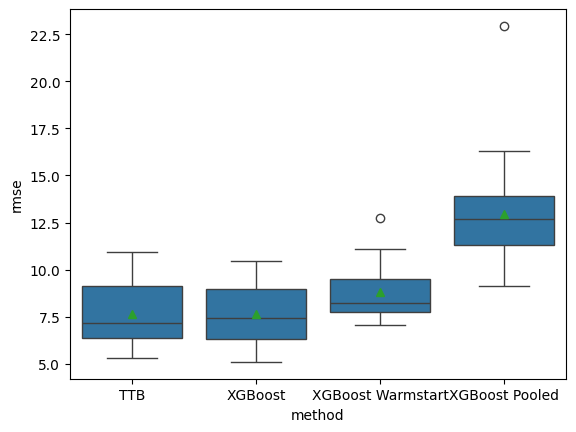

In [23]:
sub_name = 'volume'

dat = pd.read_csv(f'results_{sub_name}/ttb_LS.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_LSTransferTreeBoost_params = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results_{sub_name}/xgb.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, best_XGBoost_params = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost['method'] = 'XGBoost'

data = pd.read_csv(f'results_{sub_name}/xgb_warmstart.csv')
xgboost_data_warmstart = data
xgboost_data_warmstart ['method'] = 'XGBoost Warmstart'

best_XGBoost_warmstart , best_XGBoost_params_warmstart  = topk_per_d_per_method(
    xgboost_data_warmstart ,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost_warmstart ['method'] = 'XGBoost Warmstart'

data = pd.read_csv(f'results_{sub_name}/xgb_naive.csv')
xgboost_data_pooled = data
xgboost_data_pooled ['method'] = 'XGBoost Pooled'

best_XGBoost_pooled , best_XGBoost_params_pooled  = topk_per_d_per_method(
    xgboost_data_pooled ,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost_pooled['method'] = 'XGBoost Pooled'

# data = pd.read_csv(f'results_{sub_name}/two_trada.csv')
# trada_data = data
# trada_data['method'] = 'two-stage TrAdaBoost.R2'

# best_trada, best_trada_params = topk_per_d_per_method(
#     trada_data,
# ['lr', 'n_estimators'], k=nr_of_seeds
# )
# best_trada['method'] = 'two-stage TrAdaBoost.R2'



df = best_LSTransferTreeBoost
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
df = pd.concat([df, best_XGBoost_warmstart])
df = pd.concat([df, best_XGBoost_pooled])
#df = pd.concat([df, best_trada])
marker_dict = {
'TransferTreeBoost': 'o',
'XGBoost': '^',
}

linestyles_dict = {
    'LSTransferTreeBoost': '-',
    'XGBoost': '--', 
}
    
linestyles_dict=['-', '--']


sns.boxplot(
data=df,
x='method', y='rmse', showmeans = True)





In [24]:
#Obtain best parameters in order based on test rmse
dat = pd.read_csv(f'results_{sub_name}/ttb_LS.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_LSTransferTreeBoost_params = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=100000
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results_{sub_name}/xgb.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, best_XGBoost_params = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=100000
)
best_XGBoost['method'] = 'XGBoost'

data = pd.read_csv(f'results_{sub_name}/xgb_warmstart.csv')
xgboost_data_warmstart = data
xgboost_data_warmstart ['method'] = 'XGBoost Warmstart'

best_XGBoost_warmstart , best_XGBoost_params_warmstart  = topk_per_d_per_method(
    xgboost_data_warmstart ,
['v', 'target_tree_size'], k=100000
)
best_XGBoost_warmstart ['method'] = 'XGBoost Warmstart'

data = pd.read_csv(f'results_{sub_name}/xgb_naive.csv')
xgboost_data_pooled = data
xgboost_data_pooled ['method'] = 'XGBoost Pooled'

best_XGBoost_pooled , best_XGBoost_params_pooled  = topk_per_d_per_method(
    xgboost_data_pooled ,
['v', 'target_tree_size'], k=100000
)
best_XGBoost_pooled['method'] = 'XGBoost Pooled'

# data = pd.read_csv(f'results_{sub_name}/two_trada.csv')
# trada_data = data
# trada_data['method'] = 'two-stage TrAdaBoost.R2'

# best_trada, best_trada_params = topk_per_d_per_method(
#     trada_data,
# ['lr', 'n_estimators'], k=100000
# )
# best_trada['method'] = 'two-stage TrAdaBoost.R2'

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_13280\819310077.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_13280\819310077.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_13280\819310077.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

In [25]:
#Get best params in order
best_LSTransferTreeBoost_params.iloc[::nr_of_seeds]

,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,avg_mae,n_seeds,seed,epochs,val_rmse,val_mae,rmse,mae,method
1287,0.30,1.0,2.0,0.00,0.5,7.623141,5.296716,30,877.0,400.0,5.683645,4.049541,9.635693,5.387581,TransferTreeBoost
308,0.10,1.0,2.0,0.00,0.5,7.678948,5.366712,30,864.0,400.0,7.216241,5.872285,6.973179,5.147461,TransferTreeBoost
294,0.20,1.0,2.0,0.00,0.5,7.680863,5.367180,30,864.0,400.0,7.399133,5.915563,6.933154,5.108764,TransferTreeBoost
1691,0.20,2.0,2.0,0.00,0.5,7.700256,5.349551,30,883.0,400.0,7.701935,5.470801,6.183990,4.365353,TransferTreeBoost
338,0.05,1.0,2.0,0.00,0.5,7.705345,5.396349,30,864.0,400.0,7.013135,5.821694,7.047800,5.189787,TransferTreeBoost
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1243,0.20,3.0,2.0,0.01,0.9,10.169490,7.654294,30,877.0,400.0,5.574578,3.866672,9.702513,5.588509,TransferTreeBoost
495,0.30,2.0,2.0,0.01,0.9,10.192041,7.613649,30,866.0,400.0,16.225938,11.614813,12.868989,10.885396,TransferTreeBoost
1536,0.20,1.0,2.0,0.01,0.9,10.222556,7.747510,30,881.0,400.0,10.947495,9.363867,13.258334,10.967718,TransferTreeBoost
1306,0.20,2.0,2.0,0.01,0.9,10.263047,7.704402,30,878.0,400.0,8.394608,5.741849,6.335827,5.004375,TransferTreeBoost


In [26]:
#Get best params in order
best_XGBoost_params.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
1257,0.250,1.0,7.667327,5.296526,30,1288,876.0,5.561655,4.373795,9.541385,6.182238,XGBoost
345,0.200,1.0,7.676217,5.295813,30,350,864.0,7.543929,6.062942,7.834675,5.608219,XGBoost
640,0.225,1.0,7.677334,5.273855,30,665,868.0,6.669817,4.747303,8.794026,5.965609,XGBoost
18,0.150,1.0,7.684421,5.299788,30,28,860.0,5.466306,4.314261,5.794829,4.595219,XGBoost
176,0.125,1.0,7.693279,5.307179,30,175,862.0,7.423415,5.216718,9.771558,5.796854,XGBoost
...,...,...,...,...,...,...,...,...,...,...,...,...
401,0.300,7.0,8.333151,5.783879,30,461,865.0,10.417118,6.270694,6.226488,4.851451,XGBoost
271,0.150,7.0,8.334975,5.789308,30,265,863.0,6.569746,5.074320,10.703870,6.389772,XGBoost
1270,0.275,7.0,8.338920,5.808811,30,1301,876.0,6.956924,5.296039,9.985689,6.833802,XGBoost
2297,0.075,7.0,8.373951,5.804337,30,2246,889.0,8.037333,5.755734,6.358602,4.520801,XGBoost


In [27]:
#Get best params in order
best_XGBoost_params_warmstart.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
2101,0.050,1.0,8.808536,6.244985,30,2079,887.0,10.909192,6.691564,7.421240,5.983272,XGBoost Warmstart
542,0.050,2.0,9.026449,6.436745,30,540,867.0,9.450635,5.267883,10.548731,6.232855,XGBoost Warmstart
458,0.075,1.0,9.142120,6.501329,30,392,865.0,12.314461,8.574764,8.590050,6.466953,XGBoost Warmstart
1198,0.050,3.0,9.263695,6.626859,30,1157,875.0,11.289166,8.165829,8.451893,6.651912,XGBoost Warmstart
489,0.075,2.0,9.444752,6.722760,30,470,866.0,9.905441,6.179400,10.005296,7.165217,XGBoost Warmstart
...,...,...,...,...,...,...,...,...,...,...,...,...
373,0.250,7.0,29.527310,20.451788,30,370,864.0,31.190090,22.626433,29.389824,19.285062,XGBoost Warmstart
142,0.275,6.0,30.006878,20.682681,30,145,861.0,35.370075,23.650607,26.755640,17.813315,XGBoost Warmstart
538,0.300,6.0,31.002965,21.503348,30,537,866.0,29.057337,20.527764,29.143019,20.391417,XGBoost Warmstart
1270,0.275,7.0,32.145030,22.115437,30,1301,876.0,24.750990,17.356309,31.215993,22.374680,XGBoost Warmstart


In [28]:
best_XGBoost_params_pooled.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
2290,0.100,7.0,12.946259,9.314702,30,2253,889.0,10.373156,7.999974,11.584209,9.558747,XGBoost Pooled
912,0.075,7.0,13.137027,9.369418,30,860,871.0,15.842453,10.434578,10.739670,8.825213,XGBoost Pooled
1817,0.050,7.0,13.411103,9.691847,30,1777,883.0,8.384924,6.667356,14.888493,9.566795,XGBoost Pooled
17,0.125,7.0,13.412203,9.444122,30,27,860.0,15.180874,10.133863,14.712692,9.448742,XGBoost Pooled
160,0.050,6.0,13.452321,10.029173,30,159,862.0,13.116799,10.314934,14.235409,10.510032,XGBoost Pooled
...,...,...,...,...,...,...,...,...,...,...,...,...
806,0.150,1.0,137.806968,128.898518,30,798,870.0,157.354269,151.620440,154.734374,149.014556,XGBoost Pooled
1196,0.050,1.0,137.918005,137.043696,30,1155,875.0,139.361543,138.596836,139.507744,138.359397,XGBoost Pooled
300,0.075,1.0,141.822601,140.003085,30,238,863.0,145.499655,144.078909,138.693647,136.597911,XGBoost Pooled
433,0.100,1.0,145.899211,142.832313,30,399,865.0,148.667177,145.717593,153.561003,151.043065,XGBoost Pooled


In [29]:
#best_trada_params.iloc[::nr_of_seeds]

In [30]:
((best_XGBoost_params.iloc[0]['avg_rmse'] - best_LSTransferTreeBoost_params.iloc[0]['avg_rmse']) / best_XGBoost_params.iloc[0]['avg_rmse'])*100

np.float64(0.5762898423400772)

In [31]:
#Get best params in order
import numpy as np
print(
    np.round(best_LSTransferTreeBoost_params['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_LSTransferTreeBoost_params['rmse']), 3), "&",
    np.round(best_XGBoost_params['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_XGBoost_params['rmse']), 3), "&",
    np.round(best_XGBoost_params_warmstart['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_XGBoost_params_warmstart['rmse']), 3), "&",
    np.round(best_XGBoost_params_pooled['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_XGBoost_params_pooled['rmse']), 3)
)

7.623 & 2.222 & 7.667 & 1.646 & 8.809 & 7.176 & 12.946 & 38.84
